## RDA (Análise Discriminante Regularizada)

Colab de referência: https://colab.research.google.com/drive/1KyyJUAWqp15cqjTF_YQeSdCHZTPA04ic

Características:

* É uma extensão balanceada (meio-termo) do LDA e QDA;
* LDA assume que as classes têm a **mesma** matriz de covariância, equanto QDA assume **diferentes** matrizes para cada classe;
* **RDA** introduz **parâmetro de regularização** que ajusta o grau de suavização entre as abordagens LDA e QDA;
* É um *trade-off* entre a simplicidade do LDA e a flexibilidade do QDA;
* Adequado para situações em que se deseja evitar o *overfitting* (comum no QDA) e o *underfitting* (potencial no LDA);
* A regularização permitida pelo RDA possibilita um desempenho mais robuto, equilibrando capacidade de generalização e modelagem precisa dos dados.

In [1]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import seaborn as sns

# carregar o dataset
iris = load_iris(as_frame=True)
df = iris.frame

# X armazena as caractéristicas
X = df.iloc[:, :-1].values

# y armazena os rótulos (classificação) das espécies
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("------")
print(f"Qtd de elementos para treino: {X_train.shape[0]}")
print(f"Qtd de rótulos para treino: {X_test.shape[0]}")

print("------")

print(f"Qtd de elementos para teste: {y_train.shape[0]}")
print(f"Qtd de rótulos para teste: {y_test.shape[0]}")

# cria e treino o modelo (LDA com shrinkage)
rda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
rda.fit(X_train, y_train)

# obtem as predições
y_pred_rda_train = rda.predict(X_train)
y_pred_rda_test = rda.predict(X_test)

# calcular a acurácia
print("\nCalculando a acurácia ...")
rda_train_acc = accuracy_score(y_train, y_pred_rda_train)
print('Treino:', round(rda_train_acc * 100, 2),'%')

rda_test_acc = accuracy_score(y_test, y_pred_rda_test)
rda_test_acc = rda_test_acc* 100
print(f"Teste: {rda_test_acc:.2f} %")

# Verificar onde foi o erro?

# pegar o dataset, exceto última coluna que contem a classificação
df_rda_train = pd.DataFrame(X_train, columns=df.iloc[:, :-1].columns)

# adiciona uma coluna com os rótulos usados no treino
df_rda_train['species'] = y_train

# adiciona outra nova coluna com os rótulos preditos
df_rda_train['species_predictec'] = y_pred_rda_train

# criar nova df para armazenar os erros
df_rda_train_erros = df_rda_train.query('species != species_predictec')

# df_rda_train.head()
df_rda_train_erros.head()

------
Qtd de elementos para treino: 105
Qtd de rótulos para treino: 45
------
Qtd de elementos para teste: 105
Qtd de rótulos para teste: 45

Calculando a acurácia ...
Treino: 97.14 %
Teste: 100.00 %


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_predictec
1,6.3,2.8,5.1,1.5,2,1
44,5.9,3.2,4.8,1.8,1,2
47,6.0,2.7,5.1,1.6,1,2


<Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>

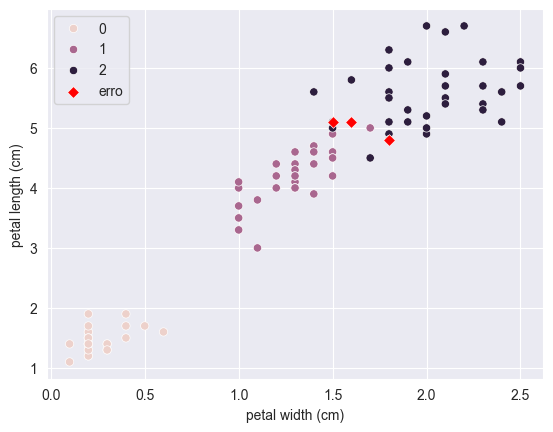

In [2]:
# plotando o gráfico com realce nos erros
sns.scatterplot(df_rda_train.sort_values(by='species'),
                x='petal width (cm)',
                y='petal length (cm)',
                hue='species')

sns.scatterplot(df_rda_train_erros.sort_values(by='species'),
                x='petal width (cm)',
                y='petal length (cm)',
                color = 'r',
                marker='D',
                label= 'erro')